In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)



In [3]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers","footer","quotes")
)
tet_data = fetch_20newsgroups(
    subset="test",
    remove=("header","footer","quotes")
)


    

In [4]:
train_data = fetch_20newsgroups(subset='train')
test_data = fetch_20newsgroups(subset='test')

x_train_text = train_data.data
y_train = train_data.target

x_test_text = test_data.data
y_test = test_data.target

class_name = train_data.target_names


In [5]:
print("Training documents:", len(x_train_text))
print("Testing documents:", len(x_test_text))
print("Number of classes:", len(class_name))


Training documents: 11314
Testing documents: 7532
Number of classes: 20


In [6]:
Vectorizer = CountVectorizer(
    stop_words="english",
        min_df=2
)
x_train = Vectorizer.fit_transform(x_train_text)
x_test = Vectorizer.transform(x_test_text)



In [8]:
print("Training features matrix:",x_train.shape)
print("Testing features matrix:",x_test.shape)



Training features matrix: (11314, 56126)
Testing features matrix: (7532, 56126)


In [13]:
mnb = MultinomialNB()

mnb.fit(
    x_train,
    y_train
)

y_pred_mnb = mnb.predict(x_test)


In [16]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
x_train_binary=binary_vectorizer.fit_transform(
    x_train_text
)
x_test_binary = binary_vectorizer.transform(
    x_test_text
)


In [19]:
bnb = BernoulliNB()

bnb.fit(
    x_train_binary,
    y_train
)

y_pred_bnb = bnb.predict(
    x_test_binary
)


In [24]:
results = pd.DataFrame({
    "Model": [
        "Multinomial NB",
        "Bernoulli NB"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],

    "Precision": [
        precision_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        precision_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        recall_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        f1_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ]
})



        
    



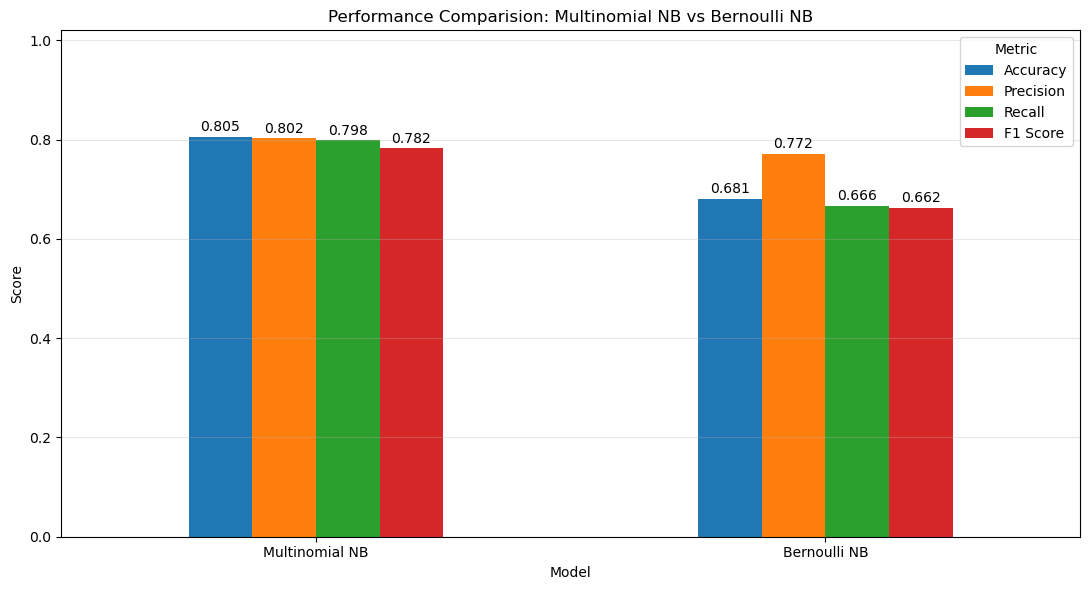

In [33]:
results_metrics = results[
     ["Model", "Accuracy","Precision","Recall","F1 Score"]
    ]

ax = results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)
plt.title(
    "Performance Comparision: Multinomial NB vs Bernoulli NB"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
    axis="y",
    alpha=0.3
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )
plt.tight_layout()
plt.show()
           

